# Exploratory Data Analysis — Ontario Weather Data

This notebook explores and validates the Ontario daily weather dataset created in Notebook 1 before the weather variables are incorporated into the demand forecasting.

---


### Objectives

The exploratory analysis focuses on:

- data quality and completeness,
- distributions and extreme observations,
- relationships between weather variables,
- temperature patterns over time,
- annual seasonality, and
- the frequency of notable weather conditions.

The results will provide the exploratory foundation for the weather feature engineering and
selection performed in the demand forecasting phase.

In [3]:
# Import libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Data Loading & Validation

### 1.1 Load Weather Dataset

In [4]:
# import data
df = pd.read_csv('../data/ontario_daily_weather_2017_2025.csv') 

### 1.2 Descriptive Summary

Inspect the dataset dimensions, data types, summary statistics, and missing-value counts
before beginning the visual analysis.


In [5]:
print('Shape:', df.shape)
display(df.info())
display(df.describe())
print('Missing values:\n', df.isnull().sum())

Shape: (3287, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               3287 non-null   object 
 1   Temp_Mean          3287 non-null   float64
 2   Temp_Max           3287 non-null   float64
 3   Temp_Min           3287 non-null   float64
 4   Relative_Humidity  3287 non-null   float64
 5   Dew_Point          3287 non-null   float64
 6   Precipitation      3287 non-null   float64
 7   Snowfall           3287 non-null   float64
 8   Rainfall_Est       3287 non-null   float64
 9   Snow_Depth         3287 non-null   float64
 10  Solar_Level        3287 non-null   float64
 11  Cloud_Amount       3287 non-null   float64
 12  Wind_Speed         3287 non-null   float64
dtypes: float64(12), object(1)
memory usage: 334.0+ KB


None

,Temp_Mean,Temp_Max,Temp_Min,Relative_Humidity,Dew_Point,Precipitation,Snowfall,Rainfall_Est,Snow_Depth,Solar_Level,Cloud_Amount,Wind_Speed
count,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000
mean,1.780878,6.699040,-2.467947,84.903627,-1.096279,1.868509,0.791377,1.222468,12.546526,139.607215,68.654413,3.008435
std,12.912498,13.426859,12.647688,8.952637,11.469650,1.965638,1.319181,1.904377,12.239739,81.800213,17.207067,0.760555
min,-31.989429,-26.267429,-37.896571,59.337143,-31.867714,0.012571,0.000000,0.000000,0.000000,13.918857,6.247143,1.427143
25%,-9.023143,-4.525286,-12.744286,77.647143,-10.323714,0.540286,0.000000,0.000000,0.036000,60.020714,57.018714,2.455714
50%,2.675714,7.182571,-1.080571,84.414000,-0.702571,1.190000,0.235714,0.330286,11.095143,139.161429,70.389429,2.885429
75%,14.077714,19.613571,9.271286,93.916714,9.667000,2.490714,1.039286,1.692000,21.971857,207.695857,82.715714,3.412714
max,23.582000,29.362571,19.197143,99.016000,19.079143,16.184571,12.164571,16.118000,40.147714,347.076286,98.965143,8.176857


Missing values:
 Date                 0
Temp_Mean            0
Temp_Max             0
Temp_Min             0
Relative_Humidity    0
Dew_Point            0
Precipitation        0
Snowfall             0
Rainfall_Est         0
Snow_Depth           0
Solar_Level          0
Cloud_Amount         0
Wind_Speed           0
dtype: int64


### 1.3 Data Transformation

Convert the date column to a datetime type, and set it as the time-series index.


In [6]:
# Convert date to datetime and set index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

---
## 2. Temperature Analysis

Temperature is examined first because it is one of the clearest continuous indicators of
weather conditions and provides an initial view of the dataset's temporal behaviour.

### 2.1 Temperature Over Time

Plot mean daily temperature across the full observation period to inspect long-term
variation and recurring seasonal patterns.


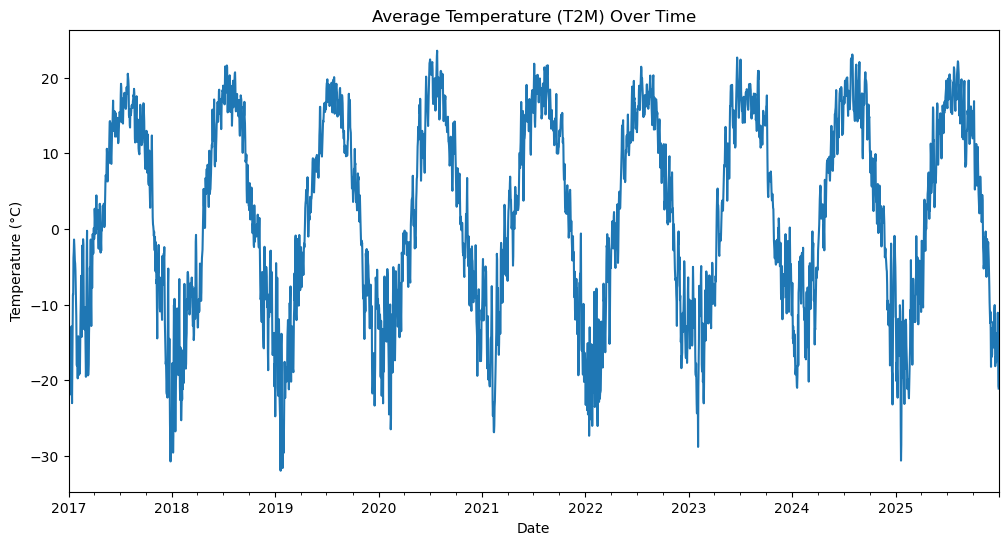

In [7]:
#  Average Temperature plot
plt.figure(figsize=(12,6))
df['Temp_Mean'].plot()
plt.title('Average Temperature (T2M) Over Time')
plt.ylabel('Temperature (°C)')
plt.show()

### 2.2 Temperature Distribution & Outliers

Compare mean, maximum, and minimum temperatures using boxplots. The IQR calculation is
also used to identify potential outliers across all numeric weather variables.


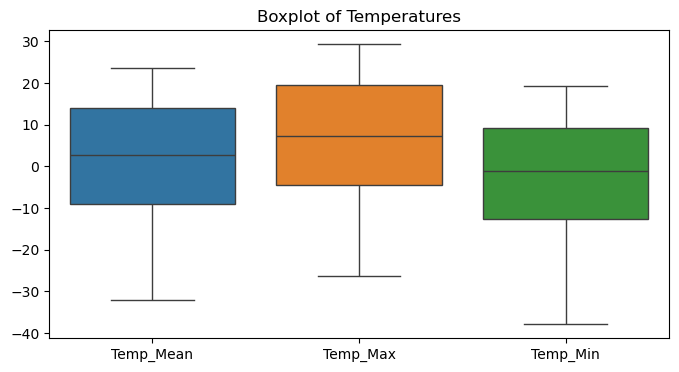

IQR: 
Temp_Mean             23.100857
Temp_Max              24.138857
Temp_Min              22.015571
Relative_Humidity     16.269571
Dew_Point             19.990714
Precipitation          1.950429
Snowfall               1.039286
Rainfall_Est           1.692000
Snow_Depth            21.935857
Solar_Level          147.675143
Cloud_Amount          25.697000
Wind_Speed             0.957000
dtype: float64


Outliers Sum: 
Temp_Mean              0
Temp_Max               0
Temp_Min               0
Relative_Humidity      0
Dew_Point              0
Precipitation        209
Snowfall             268
Rainfall_Est         256
Snow_Depth             0
Solar_Level            0
Cloud_Amount           6
Wind_Speed            78
dtype: int64


In [8]:
# Boxplot for temperatures
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['Temp_Mean', 'Temp_Max', 'Temp_Min']])
plt.title('Boxplot of Temperatures')
plt.show()

# Display the IQR for each variable
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(f"IQR: \n{IQR}")

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print(f"\n\nOutliers Sum: \n{outliers.sum()}")



---
## 3. Weather Variable Distributions & Events

### 3.1 Key Weather Variable Distributions

Examine the distributions of selected weather variables. These plots help identify
skewness, concentration near zero, extreme observations, and differences in scale before
the variables are used in later modelling.


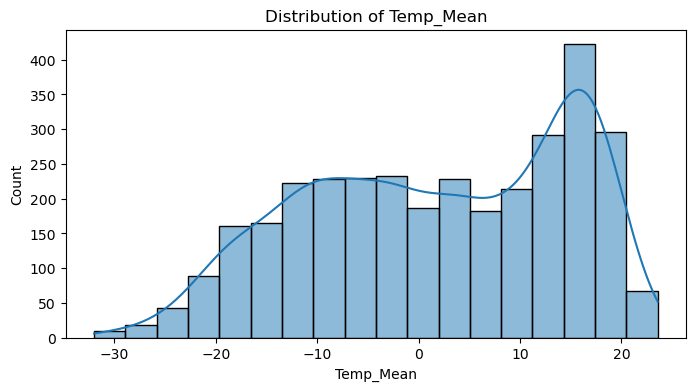

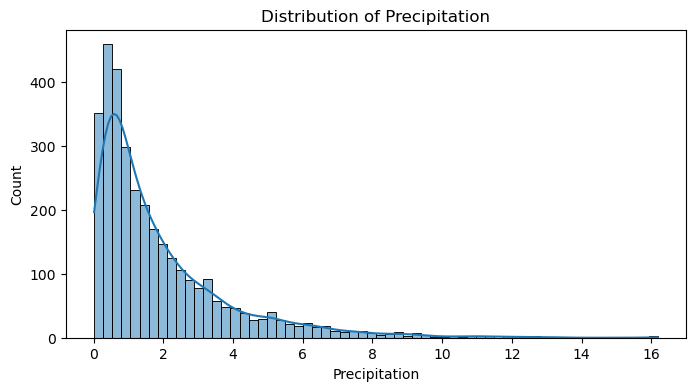

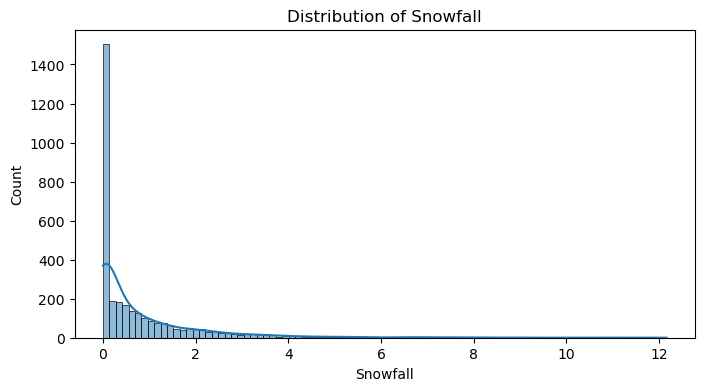

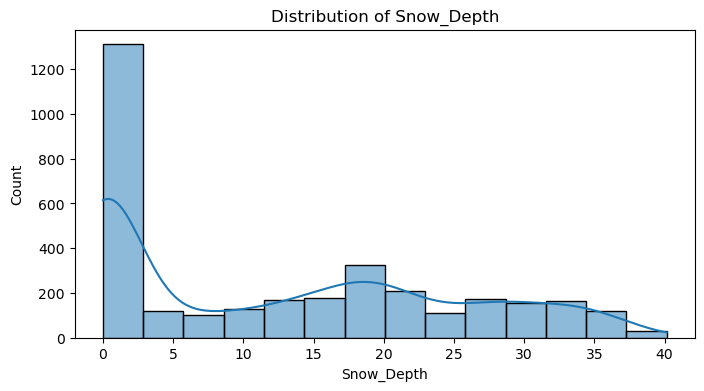

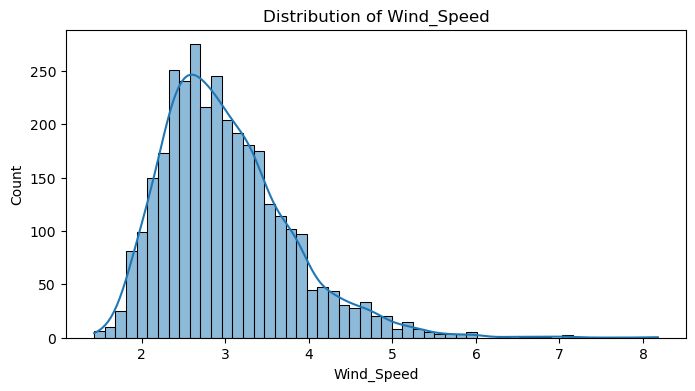

In [9]:
# Histograms for key vars
key_vars = ['Temp_Mean', 'Precipitation', 'Snowfall', 'Snow_Depth', 'Wind_Speed']
for var in key_vars:
    plt.figure(figsize=(8,4))
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

### 3.2 Frequency of Weather Events

Count days associated with snowfall, rainfall, high cloud cover, and extreme cold to
provide an interpretable summary of how frequently these conditions occur in the dataset.


In [10]:
#count of Snow days, rain days, cloudy days, and extremes
total_days = df.shape[0]
snow_days = df[df['Snowfall'] > 0].shape[0]
no_snow_days = total_days - snow_days
rain_days = df[df['Rainfall_Est'] > 0].shape[0]
no_rain_days = total_days - rain_days
cloudy_days = df[df['Cloud_Amount'] > 50].dropna(subset=['Cloud_Amount']).shape[0]  # Threshold >50% for cloudy
extreme_cold = df[df['Temp_Min'] < -20].shape[0]

print('Total days:', total_days)
print('Days with snowfall (>0 mm):', snow_days)
print('Days without snowfall:', no_snow_days)
print('Days with rain (>0 mm):', rain_days)
print('Days without rain:', no_rain_days)
print('Days that were cloudy (>50% cloud amount):', cloudy_days)
print('Days with extreme cold (min < -20°C):', extreme_cold)

Total days: 3287
Days with snowfall (>0 mm): 2269
Days without snowfall: 1018
Days with rain (>0 mm): 2156
Days without rain: 1131
Days that were cloudy (>50% cloud amount): 2770
Days with extreme cold (min < -20°C): 362


---
## 4. Correlation Analysis

Performed a correlation matrix to examine linear relationships among the weather variables and
identify groups of variables that may contain overlapping information.


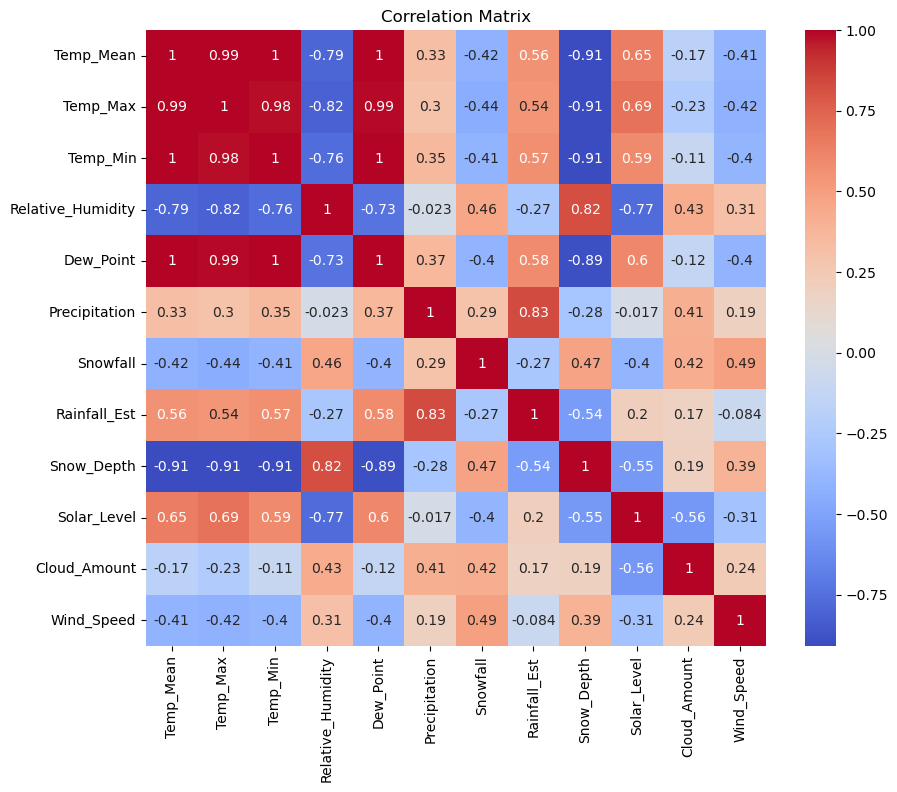

In [11]:
# Correlation heatmap
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The correlation analysis is used primarily as a screening step before feature engineering.
Strong relationships among related weather measures can indicate redundant information,
while weaker relationships may identify variables carrying distinct signals.

This is especially relevant for the forecasting phase, where highly overlapping weather
variables may increase multicollinearity without adding useful predictive information.


---
## 5. Seasonal Decomposition

Decompose mean daily temperature using an additive model with a 365-day period to separate
the observed series into trend, seasonal, and residual components.


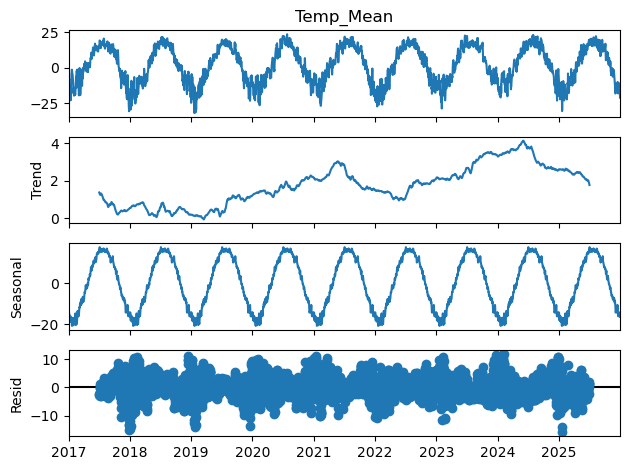

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Seasonal decomposition (for T2M)
decomp = seasonal_decompose(df['Temp_Mean'], model='additive', period=365)
decomp.plot()
plt.show()

The decomposition provides a direct view of the recurring annual temperature cycle in the
daily weather series. This seasonal structure is important for the later forecasting
analysis because retail demand also contains strong seasonality.

Weather variables therefore need to be evaluated based on whether they provide information
beyond patterns that a seasonal forecasting model can already capture.